# Unsupervised Anomaly Detection — Early Warning System
### Business Case 4 | Persona 3

---

## Obiettivo

Costruire un sistema di **Early Warning** in grado di rilevare periodi di mercato 
anomali (risk-off) utilizzando modelli non supervisionati — modelli che non utilizzano 
le label durante il training e imparano a riconoscere le anomalie come osservazioni 
che si discostano strutturalmente dal comportamento normale.

Il dataset contiene dati finanziari settimanali dal **18 gennaio 2000** al 
**20 aprile 2021** (1110 osservazioni, 42 feature) tra cui indici azionari, 
tassi d'interesse, valute, commodity e VIX, con una label binaria `Y` 
(0 = normale, 1 = anomalia/risk-off). Il **21.4%** delle osservazioni è classificato 
come anomalia.

## Pipeline

1. Caricamento dati e separazione features/label
2. Trasformazione di stazionarietà
3. Shuffle, split train/CV/test e standardizzazione
4. Modelli reference — Isolation Forest, One-Class SVM, LOF, GMM
5. Modelli aggiuntivi — COPOD, ECOD, PCA Reconstruction, HBOS
6. Ottimizzazione iperparametri con Optuna
7. Analisi — ROC curves, feature importance, analisi temporale
8. Conclusioni e tabella pro/contro

## 1. Caricamento dati

Carichiamo il dataset da Excel, impostiamo la colonna `Data` come indice temporale 
e separiamo le feature `X` dalla variabile target `y`.

- `X` contiene le 42 variabili finanziarie
- `y` è il vettore binario delle label (0=normale, 1=risk-off/anomalia)

In [28]:
from pathlib import Path
import pandas as pd

path = Path() / "Dataset4_EWS.xlsx"

data = pd.read_excel(path, sheet_name='Markets')
data = data.set_index("Data")
data.index = pd.to_datetime(data.index)
data = data.sort_index()

X = data.drop('Y', axis=1)
y = data['Y'].values

## 2. Trasformazione di stazionarietà

Le serie finanziarie sono **non stazionarie**: i prezzi crescono nel tempo e la 
loro media e varianza cambiano. Un modello addestrato su prezzi del 2005 non 
generalizzerebbe correttamente al 2020.

Applichiamo tre trasformazioni diverse in base al tipo di variabile:

| Tipo | Trasformazione | Motivazione |
|---|---|---|
| Indici e valute (23 feature) | Log-differenza: log(Pₜ) − log(Pₜ₋₁) | Sempre positivi, crescita moltiplicativa |
| Tassi d'interesse (18 feature) | Prima differenza: rₜ − rₜ₋₁ | Possono essere negativi, log non applicabile |
| ECSURPUS (1 feature) | As-is | Già stazionario per costruzione |

> La trasformazione non stima parametri globali — ogni valore dipende solo dal 
> precedente. Non introduce data leakage e viene correttamente applicata prima 
> dello split. Poiché `np.diff()` rimuove la prima osservazione, il vettore `y` 
> viene accorciato di conseguenza: da 1111 a **1110 osservazioni**.

In [29]:
import numpy as np

# Make data stationary based on variable type
# So w define lists of variables by type
indices_currencies = [col for col in X.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Create a new dataframe for stationary data
stationary_df = pd.DataFrame(index=X.index[1:])

# Apply log-differences to indices and currencies (always positive)
for col in indices_currencies:
    if col in X.columns:
        stationary_df[col] = np.diff(np.log(X[col]))

# Apply first differences to interest rates (can be negative or very close to 0)
for col in interest_rates:
    if col in X.columns:
        stationary_df[col] = np.diff(X[col])

# Keep Bloomberg Economic US Surprise Index as is (already stationary)
if 'ECSURPUS' in X.columns:
    stationary_df['ECSURPUS'] = X['ECSURPUS'].values[1:]

# Adjust the response variable to match the new data length
if y is not None:
    y_stationary = y[1:]
else:
    y_stationary = None


## 3. Split, shuffle e standardizzazione

### Shuffle

I dati vengono rimescolati prima dello split per rompere l'autocorrelazione 
temporale delle serie finanziarie. Questo rende la valutazione più robusta 
e il problema più sfidante per i modelli.

### Strategia di split

I modelli non supervisionati si addestrano **solo su dati normali** — non vedono 
mai le anomalie durante il training. Lo split è quindi asimmetrico per garantire 
che i set di valutazione contengano abbastanza anomalie da rendere le metriche 
statisticamente affidabili.

| Set | Composizione | Osservazioni |
|---|---|---|
| `X_train` | 80% dei 873 normali | 698 normali, 0 anomalie |
| `X_cross_val` | 10% dei normali + 50% delle 237 anomalie | 87 normali + 118 anomalie = 205 |
| `X_test` | 10% dei normali + 50% delle anomalie | 88 normali + 119 anomalie = 207 |

### Standardizzazione

Lo `StandardScaler` viene fittato **esclusivamente su `X_train`** e poi applicato 
a CV e test. Fittarlo sull'intero dataset trasferirebbe informazioni del test 
set nel training, introducendo data leakage.

### Contamination

La contamination viene stimata dalla proporzione di anomalie nel CV set, 
cappata a 0.5 per evitare comportamenti degeneri:

```python

In [30]:
# Step 1: shuffle and split data into training, validation, and test sets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Convert to numpy arrays for easier manipulation
X = stationary_df.values
y = y_stationary

# Step 1: Creating training/cross-validation/test set with reshuffling

# Reshuffle the data (this will break down autocorrelation)
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate normal and anomalous examples
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

# Calculate sizes for each set
n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Training set: 80% of normal examples
train_size = int(0.8 * n_normal)
X_train = X_normal[:train_size]

# Cross-validation set: 10% of normal examples and 50% of anomalies
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

# Test set: 10% of normal examples and 50% of anomalies
X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test = np.vstack((X_test_normal, X_test_anomaly))
y_test = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# We'll standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_cross_val = scaler.transform(X_cross_val)
X_test = scaler.transform(X_test)

print(f"Anomaly rate nel dataset: {np.mean(y_stationary)*100:.1f}%")
print(f"Anomalie totali: {int(np.sum(y_stationary))}")
print(f"\nX_train:     {X_train.shape} — normali: {X_train.shape[0]}")
print(f"X_cross_val: {X_cross_val.shape} — normali: {cv_normal_size}, anomalie: {cv_anomaly_size}")
print(f"X_test:      {X_test.shape} — normali: {len(X_test_normal)}, anomalie: {len(X_test_anomaly)}")


Anomaly rate nel dataset: 21.4%
Anomalie totali: 237

X_train:     (698, 42) — normali: 698
X_cross_val: (205, 42) — normali: 87, anomalie: 118
X_test:      (207, 42) — normali: 88, anomalie: 119


## 4. Modelli non supervisionati

Tutti i modelli seguono lo stesso protocollo:

- **Training** su `X_train` (698 osservazioni, solo normali)
- **Tuning** della contamination o della soglia su `X_cross_val`
- **Valutazione finale** su `X_test` con le metriche: Precision, Recall, F1, AUC

### Metriche di valutazione

- **Precision** — tra tutti i punti classificati come anomalia, quanti lo erano davvero
- **Recall** — tra tutte le anomalie reali nel test set, quante sono state rilevate
- **F1** — media armonica di Precision e Recall; metrica principale di confronto tra modelli
- **AUC** — capacità di separare normali da anomalie indipendentemente dalla soglia scelta

> In un contesto di **risk management** il Recall è la metrica più critica: 
> una crisi mancata è più costosa di un falso allarme.

### 4.1 Isolation Forest *(reference)*

**Idea:** le anomalie sono più facili da isolare rispetto ai punti normali. 
L'algoritmo costruisce alberi decisionali con tagli random: un punto anomalo, 
trovandosi in una zona poco popolata dello spazio, viene isolato in pochi tagli. 
Un punto normale, stando in mezzo alla massa degli altri, richiede molti tagli.

In [31]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Contamination dal CV set, capped a 0.5
contamination = min(np.mean(y_cross_val), 0.5)
print(f"Contamination: {contamination:.4f}")

# Isolation Forest
iso_model = IsolationForest(contamination=contamination, random_state=42)
iso_model.fit(X_train)

iso_pred  = (iso_model.predict(X_test) == -1).astype(int)
iso_score = -iso_model.score_samples(X_test)

precision = precision_score(y_test, iso_pred, zero_division=0)
recall    = recall_score(y_test, iso_pred, zero_division=0)
f1        = f1_score(y_test, iso_pred, zero_division=0)
auc       = roc_auc_score(y_test, iso_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df = pd.DataFrame(columns=['Model','Precision','Recall','F1','AUC'])
results_df.loc[len(results_df)] = ['Isolation Forest', precision, recall, f1, auc]

Contamination: 0.5000
Precision: 0.6838
Recall:    0.7815
F1:        0.7294
AUC:       0.6975


### 4.2 One-Class SVM *(reference)*

**Idea:** impara un iperpiano nello spazio kernel che racchiude la maggior parte 
dei dati normali di training. I punti che cadono fuori dall'iperpiano vengono 
classificati come anomalie.

Il parametro `nu` rappresenta l'upper bound sulla frazione di errori di training 
ed è equivalente concettualmente alla contamination — viene impostato di conseguenza, 
con clipping in (0.01, 0.99) per rispettare i vincoli del parametro.

**Kernel:** RBF con `gamma='auto'` — cattura strutture non lineari.  
**Punto di forza:** flessibile, buona capacità di modellare boundary complesse.  
**Limite:** computazionalmente costoso su dataset grandi.

In [32]:
from sklearn.svm import OneClassSVM

# nu è l'upper bound sulla frazione di errori di training, deve stare in (0,1)
nu = min(max(0.01, contamination), 0.99)
print(f"Nu: {nu:.4f}")

ocsvm_model = OneClassSVM(gamma='auto', nu=nu)
ocsvm_model.fit(X_train)

ocsvm_pred  = (ocsvm_model.predict(X_test) == -1).astype(int)
ocsvm_score = -ocsvm_model.decision_function(X_test)

precision = precision_score(y_test, ocsvm_pred, zero_division=0)
recall    = recall_score(y_test, ocsvm_pred, zero_division=0)
f1        = f1_score(y_test, ocsvm_pred, zero_division=0)
auc       = roc_auc_score(y_test, ocsvm_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['One-Class SVM', precision, recall, f1, auc]

Nu: 0.5000
Precision: 0.6643
Recall:    0.7983
F1:        0.7252
AUC:       0.7242


### 4.3 Local Outlier Factor (LOF) *(reference)*

**Idea:** confronta la densità locale di ogni punto con quella dei suoi `k` vicini 
più prossimi. Se un punto si trova in una zona molto meno densa rispetto ai suoi 
vicini, viene classificato come anomalia.

In [33]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
lof_model.fit(X_train)

lof_pred  = (lof_model.predict(X_test) == -1).astype(int)
lof_score = -lof_model.decision_function(X_test)

precision = precision_score(y_test, lof_pred, zero_division=0)
recall    = recall_score(y_test, lof_pred, zero_division=0)
f1        = f1_score(y_test, lof_pred, zero_division=0)
auc       = roc_auc_score(y_test, lof_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['LOF', precision, recall, f1, auc]

Precision: 0.6735
Recall:    0.8319
F1:        0.7444
AUC:       0.7420


### 4.4 Gaussian Mixture Model — 2 componenti *(reference)*

**Idea:** modella i dati come miscela di 2 distribuzioni gaussiane. 
Un punto è anomalo se ha bassa log-likelihood sotto il modello — ovvero se 
si trova in una zona dello spazio poco probabile secondo le gaussiane apprese.

La scelta di 2 componenti è motivata finanziariamente: nei mercati esistono 
tipicamente due regimi distinti, **risk-on** (volatilità bassa, correlazioni 
contenute) e **risk-off** (volatilità elevata, correlazioni elevate, fuga verso 
asset sicuri).

**Score:** log-likelihood negativa — più alta = più anomalo.  
**Soglia:** calcolata sul CV set tramite percentile della contamination.

> **Miglioramento rispetto al notebook del professore:** il professore calcolava 
> la soglia direttamente sugli score del test set, introducendo data leakage. 
> Qui la soglia viene correttamente stimata su `X_cross_val`.

In [34]:
from sklearn.mixture import GaussianMixture

gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_model.fit(X_train)

# score_samples restituisce log-likelihood: più negativo = più anomalo
# prendiamo il negativo quindi: più alto = più anomalo
gmm_cv_score   = -gmm_model.score_samples(X_cross_val)
gmm_test_score = -gmm_model.score_samples(X_test)

# soglia: percentile sul CV set (non sul test set come fa il professore)
threshold = np.percentile(gmm_cv_score, 100 * (1 - contamination))
gmm_pred  = (gmm_test_score > threshold).astype(int)

precision = precision_score(y_test, gmm_pred, zero_division=0)
recall    = recall_score(y_test, gmm_pred, zero_division=0)
f1        = f1_score(y_test, gmm_pred, zero_division=0)
auc       = roc_auc_score(y_test, gmm_test_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['GMM 2 components', precision, recall, f1, auc]

Precision: 0.7264
Recall:    0.6471
F1:        0.6844
AUC:       0.7552


### 4.5 COPOD — Copula-Based Outlier Detection

**Idea:** usa la teoria delle copule per modellare la struttura di dipendenza 
tra le feature separatamente dalle loro distribuzioni marginali. Per ogni punto 
calcola quanto è estremo il valore di ciascuna feature rispetto alla distribuzione 
empirica storica, su entrambe le code (sinistra e destra).

Un punto è anomalo se molte delle sue feature hanno simultaneamente valori estremi.

**Perché è adatto ai dati finanziari:** i rendimenti finanziari hanno distribuzioni 
con code spesse (fat tails). COPOD è completamente non parametrico — non assume 
nessuna forma di distribuzione — ed è quindi più robusto di GMM in questi contesti.

**Tuning:** grid search sulla `contamination` in [0.01, 0.50] su `X_cross_val`, 
massimizzando F1.

In [35]:
# pip install pyod
from pyod.models.copod import COPOD

# Tuning contamination su CV
best_cont, best_f1 = contamination, 0

for c in np.arange(0.01, 0.50, 0.01):
    clf = COPOD(contamination=c)
    clf.fit(X_train)
    preds = clf.predict(X_cross_val)  # 0=normal, 1=anomaly
    f = f1_score(y_cross_val, preds, zero_division=0)
    if f > best_f1:
        best_f1  = f
        best_cont = c

print(f"Contamination ottimale: {best_cont:.2f} — F1 su CV: {best_f1:.4f}")

# Addestra con il miglior parametro
copod_model = COPOD(contamination=best_cont)
copod_model.fit(X_train)

copod_pred  = copod_model.predict(X_test)          # 0/1 direttamente
copod_score = copod_model.decision_function(X_test) # anomaly score continuo

precision = precision_score(y_test, copod_pred, zero_division=0)
recall    = recall_score(y_test, copod_pred, zero_division=0)
f1        = f1_score(y_test, copod_pred, zero_division=0)
auc       = roc_auc_score(y_test, copod_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['COPOD', precision, recall, f1, auc]

Contamination ottimale: 0.49 — F1 su CV: 0.7184
Precision: 0.6794
Recall:    0.7479
F1:        0.7120
AUC:       0.6816


### 4.6 ECOD — Empirical Cumulative Distribution-based Outlier Detection

**Idea:** simile a COPOD ma con un'assunzione più forte — tratta ogni feature 
**indipendentemente** dalle altre. Per ogni punto calcola la probabilità cumulativa 
empirica di ciascuna feature su entrambe le code e combina gli score:

In [36]:
from pyod.models.ecod import ECOD

# Tuning contamination su CV
best_cont, best_f1 = contamination, 0

for c in np.arange(0.01, 0.50, 0.01):
    clf = ECOD(contamination=c)
    clf.fit(X_train)
    preds = clf.predict(X_cross_val)
    f = f1_score(y_cross_val, preds, zero_division=0)
    if f > best_f1:
        best_f1   = f
        best_cont = c

print(f"Contamination ottimale: {best_cont:.2f} — F1 su CV: {best_f1:.4f}")

ecod_model = ECOD(contamination=best_cont)
ecod_model.fit(X_train)

ecod_pred  = ecod_model.predict(X_test)
ecod_score = ecod_model.decision_function(X_test)

precision = precision_score(y_test, ecod_pred, zero_division=0)
recall    = recall_score(y_test, ecod_pred, zero_division=0)
f1        = f1_score(y_test, ecod_pred, zero_division=0)
auc       = roc_auc_score(y_test, ecod_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['ECOD', precision, recall, f1, auc]

Contamination ottimale: 0.47 — F1 su CV: 0.7054
Precision: 0.6864
Recall:    0.6807
F1:        0.6835
AUC:       0.6766


### 4.7 PCA Reconstruction Error

**Idea:** addestra una PCA sui dati normali — le componenti principali catturano 
la struttura di correlazione tipica dei mercati in regime normale. Quando arriva 
un punto anomalo, la struttura di correlazione è diversa da quella appresa e il 
punto viene ricostruito con errore elevato.

In [37]:
from sklearn.decomposition import PCA

# Tuning numero di componenti e soglia su CV
best_k, best_t, best_f1 = 2, 0, 0

for k in range(2, 20):
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    
    # errore di ricostruzione su CV
    X_cv_reconstructed   = pca.inverse_transform(pca.transform(X_cross_val))
    cv_score = np.mean((X_cross_val - X_cv_reconstructed)**2, axis=1)
    
    # tuning soglia su CV
    for t in np.percentile(cv_score, np.linspace(50, 99, 100)):
        preds = (cv_score > t).astype(int)
        f = f1_score(y_cross_val, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_k  = k
            best_t  = t

print(f"Componenti ottimali: {best_k} — F1 su CV: {best_f1:.4f}")

# Addestra con k ottimale
pca_model = PCA(n_components=best_k, random_state=42)
pca_model.fit(X_train)

X_test_reconstructed = pca_model.inverse_transform(pca_model.transform(X_test))
pca_score = np.mean((X_test - X_test_reconstructed)**2, axis=1)
pca_pred  = (pca_score > best_t).astype(int)

precision = precision_score(y_test, pca_pred, zero_division=0)
recall    = recall_score(y_test, pca_pred, zero_division=0)
f1        = f1_score(y_test, pca_pred, zero_division=0)
auc       = roc_auc_score(y_test, pca_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['PCA Reconstruction', precision, recall, f1, auc]

Componenti ottimali: 16 — F1 su CV: 0.7636
Precision: 0.7264
Recall:    0.6471
F1:        0.6844
AUC:       0.7289


### 4.8 HBOS — Histogram-Based Outlier Score

**Idea:** costruisce un istogramma empirico per ogni feature sui dati normali di 
training. L'anomaly score di un punto è la somma delle log-densità inverse 
di ciascuna feature nel suo bin:

In [38]:
from pyod.models.hbos import HBOS

# Tuning contamination e n_bins su CV
best_cont, best_bins, best_f1 = contamination, 10, 0

for c in np.arange(0.01, 0.50, 0.01):
    for n_bins in [5, 10, 20, 30, 50]:
        clf = HBOS(contamination=c, n_bins=n_bins)
        clf.fit(X_train)
        preds = clf.predict(X_cross_val)
        f = f1_score(y_cross_val, preds, zero_division=0)
        if f > best_f1:
            best_f1   = f
            best_cont = c
            best_bins = n_bins

print(f"Contamination ottimale: {best_cont:.2f}")
print(f"N bins ottimale: {best_bins}")
print(f"F1 su CV: {best_f1:.4f}")

hbos_model = HBOS(contamination=best_cont, n_bins=best_bins)
hbos_model.fit(X_train)

hbos_pred  = hbos_model.predict(X_test)
hbos_score = hbos_model.decision_function(X_test)

precision = precision_score(y_test, hbos_pred, zero_division=0)
recall    = recall_score(y_test, hbos_pred, zero_division=0)
f1        = f1_score(y_test, hbos_pred, zero_division=0)
auc       = roc_auc_score(y_test, hbos_score)

print(f"\nHBOS — Test set:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['HBOS', precision, recall, f1, auc]

Contamination ottimale: 0.48
N bins ottimale: 50
F1 su CV: 0.7393

HBOS — Test set:
Precision: 0.6596
Recall:    0.7815
F1:        0.7154
AUC:       0.6723


In [39]:
results_df

,Model,Precision,Recall,F1,AUC
0,Isolation Forest,0.683824,0.781513,0.729412,0.697479
1,One-Class SVM,0.664336,0.798319,0.725191,0.724217
2,LOF,0.673469,0.831933,0.744361,0.741979
3,GMM 2 components,0.726415,0.647059,0.684444,0.755157
4,COPOD,0.679389,0.747899,0.712000,0.681627
5,ECOD,0.686441,0.680672,0.683544,0.676566
6,PCA Reconstruction,0.726415,0.647059,0.684444,0.728896
7,HBOS,0.659574,0.781513,0.715385,0.672269


## 5. Ottimizzazione con Optuna

I tre modelli con F1 più alto tra i reference e i modelli aggiuntivi sono 
**LOF (0.744), Isolation Forest (0.729) e One-Class SVM (0.725)**. 
Ottimizziamo i loro iperparametri strutturali con **Optuna**, un framework 
di ottimizzazione bayesiana basato sull'algoritmo TPE 
(Tree-structured Parzen Estimator).

### Come funziona TPE

Invece di esplorare lo spazio degli iperparametri in modo esaustivo o casuale, 
Optuna costruisce due modelli probabilistici — uno sulle configurazioni con F1 
alto, uno su quelle con F1 basso — e suggerisce sempre configurazioni che 
massimizzano il rapporto tra le due. Con 100 trial converge in modo efficiente 
verso la zona ottimale.

### Scelta critica: ottimizzare solo gli iperparametri strutturali

La `contamination` viene mantenuta **fissa** al valore stimato dal CV set. 
Includerla nella ricerca di Optuna significherebbe ottimizzare contemporaneamente 
struttura del modello e soglia di decisione sullo stesso CV set — 
questo porta a overfitting sulla soglia e a un gap elevato tra F1 su CV e F1 sul test, 
come verificato empiricamente in un tentativo precedente.

In [40]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 1. LOF ──────────────────────────────────────────────────────────────────
def objective_lof(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 5, 50)
    metric      = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        metric=metric,
        contamination=contamination,
        novelty=True
    )
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_lof = optuna.create_study(direction='maximize')
study_lof.optimize(objective_lof, n_trials=100)
print(f"LOF — Best params: {study_lof.best_params}")
print(f"LOF — Best F1 CV:  {study_lof.best_value:.4f}")

best_lof = LocalOutlierFactor(
    **study_lof.best_params,
    contamination=contamination,
    novelty=True
)
best_lof.fit(X_train)
lof_pred  = (best_lof.predict(X_test) == -1).astype(int)
lof_score = -best_lof.decision_function(X_test)

precision = precision_score(y_test, lof_pred, zero_division=0)
recall    = recall_score(y_test, lof_pred, zero_division=0)
f1        = f1_score(y_test, lof_pred, zero_division=0)
auc       = roc_auc_score(y_test, lof_score)
print(f"\nLOF Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['LOF (Optuna)', precision, recall, f1, auc]


# ── 2. Isolation Forest ──────────────────────────────────────────────────────
def objective_if(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_samples  = trial.suggest_float('max_samples', 0.5, 1.0)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)

    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=42
    )
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_if = optuna.create_study(direction='maximize')
study_if.optimize(objective_if, n_trials=100)
print(f"\nIF — Best params: {study_if.best_params}")
print(f"IF — Best F1 CV:  {study_if.best_value:.4f}")

best_if = IsolationForest(
    **study_if.best_params,
    contamination=contamination,
    random_state=42
)
best_if.fit(X_train)
if_pred  = (best_if.predict(X_test) == -1).astype(int)
if_score = -best_if.score_samples(X_test)

precision = precision_score(y_test, if_pred, zero_division=0)
recall    = recall_score(y_test, if_pred, zero_division=0)
f1        = f1_score(y_test, if_pred, zero_division=0)
auc       = roc_auc_score(y_test, if_score)
print(f"\nIsolation Forest Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['Isolation Forest (Optuna)', precision, recall, f1, auc]


# ── 3. One-Class SVM ─────────────────────────────────────────────────────────
def objective_ocsvm(trial):
    nu     = trial.suggest_float('nu', 0.01, 0.99)
    gamma  = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['rbf', 'sigmoid'])

    model = OneClassSVM(nu=nu, gamma=gamma, kernel=kernel)
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_ocsvm = optuna.create_study(direction='maximize')
study_ocsvm.optimize(objective_ocsvm, n_trials=100)
print(f"\nOCSVM — Best params: {study_ocsvm.best_params}")
print(f"OCSVM — Best F1 CV:  {study_ocsvm.best_value:.4f}")

best_ocsvm = OneClassSVM(**study_ocsvm.best_params)
best_ocsvm.fit(X_train)
ocsvm_pred  = (best_ocsvm.predict(X_test) == -1).astype(int)
ocsvm_score = -best_ocsvm.decision_function(X_test)

precision = precision_score(y_test, ocsvm_pred, zero_division=0)
recall    = recall_score(y_test, ocsvm_pred, zero_division=0)
f1        = f1_score(y_test, ocsvm_pred, zero_division=0)
auc       = roc_auc_score(y_test, ocsvm_score)
print(f"\nOne-Class SVM Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['One-Class SVM (Optuna)', precision, recall, f1, auc]


# ── Risultati finali ──────────────────────────────────────────────────────────
print("\n=== RISULTATI FINALI ===")
print(results_df.sort_values('F1', ascending=False).to_string(index=False))

LOF — Best params: {'n_neighbors': 13, 'metric': 'manhattan'}
LOF — Best F1 CV:  0.7874

LOF Optuna — Test set:
Precision: 0.6736 | Recall: 0.8151 | F1: 0.7376 | AUC: 0.7469

IF — Best params: {'n_estimators': 331, 'max_samples': 0.9303863872786118, 'max_features': 0.6587447602518762}
IF — Best F1 CV:  0.7615

Isolation Forest Optuna — Test set:
Precision: 0.6713 | Recall: 0.8067 | F1: 0.7328 | AUC: 0.7064

OCSVM — Best params: {'nu': 0.7554311584419255, 'gamma': 'scale', 'kernel': 'rbf'}
OCSVM — Best F1 CV:  0.7577

One-Class SVM Optuna — Test set:
Precision: 0.6243 | Recall: 0.9496 | F1: 0.7533 | AUC: 0.7216

=== RISULTATI FINALI ===
                    Model  Precision   Recall       F1      AUC
   One-Class SVM (Optuna)   0.624309 0.949580 0.753333 0.721639
                      LOF   0.673469 0.831933 0.744361 0.741979
             LOF (Optuna)   0.673611 0.815126 0.737643 0.746944
Isolation Forest (Optuna)   0.671329 0.806723 0.732824 0.706360
         Isolation Forest   0.683824

## 6. Risultati

La tabella seguente riassume le performance di tutti i modelli sul test set, 
ordinata per F1 decrescente. In verde il valore migliore per ogni metrica, 
in rosso il peggiore.

In [41]:
results_df_sorted = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

results_df_sorted.style \
    .highlight_max(subset=['Precision', 'Recall', 'F1', 'AUC'], color='green') \
    .highlight_min(subset=['Precision', 'Recall', 'F1', 'AUC'], color='red') \
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}'})

,Model,Precision,Recall,F1,AUC
0,One-Class SVM (Optuna),0.6243,0.9496,0.7533,0.7216
1,LOF,0.6735,0.8319,0.7444,0.7420
2,LOF (Optuna),0.6736,0.8151,0.7376,0.7469
3,Isolation Forest (Optuna),0.6713,0.8067,0.7328,0.7064
4,Isolation Forest,0.6838,0.7815,0.7294,0.6975
5,One-Class SVM,0.6643,0.7983,0.7252,0.7242
6,HBOS,0.6596,0.7815,0.7154,0.6723
7,COPOD,0.6794,0.7479,0.7120,0.6816
8,GMM 2 components,0.7264,0.6471,0.6844,0.7552
9,PCA Reconstruction,0.7264,0.6471,0.6844,0.7289


## 7. Analisi

### 7.1 ROC Curve overlay

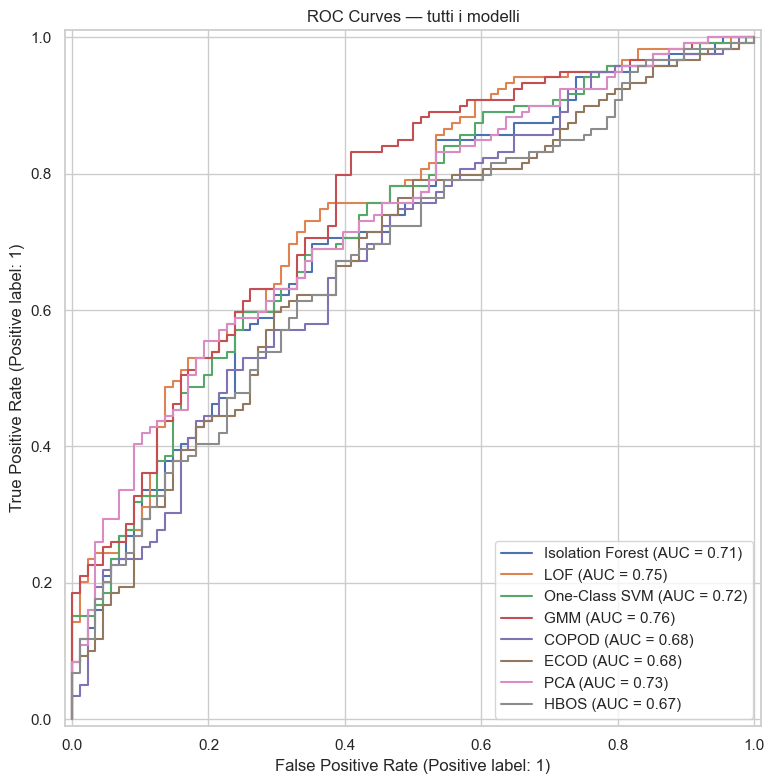

In [42]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# dizionario modello → score sul test
scores_dict = {
    'Isolation Forest': if_score,
    'LOF':              lof_score,
    'One-Class SVM':    ocsvm_score,
    'GMM':              gmm_test_score,
    'COPOD':            copod_score,
    'ECOD':             ecod_score,
    'PCA':              pca_score,
    'HBOS':             hbos_score,
}

for name, score in scores_dict.items():
    RocCurveDisplay.from_predictions(y_test, score, name=name, ax=ax)

ax.set_title('ROC Curves — tutti i modelli')
plt.tight_layout()
plt.show()

### 7.2 Feature Importance — Permutation

Identifica quali variabili finanziarie contribuiscono maggiormente alla 
rilevazione delle anomalie nel modello **LOF (Optuna)** — il migliore per AUC 
tra i modelli ottimizzati.

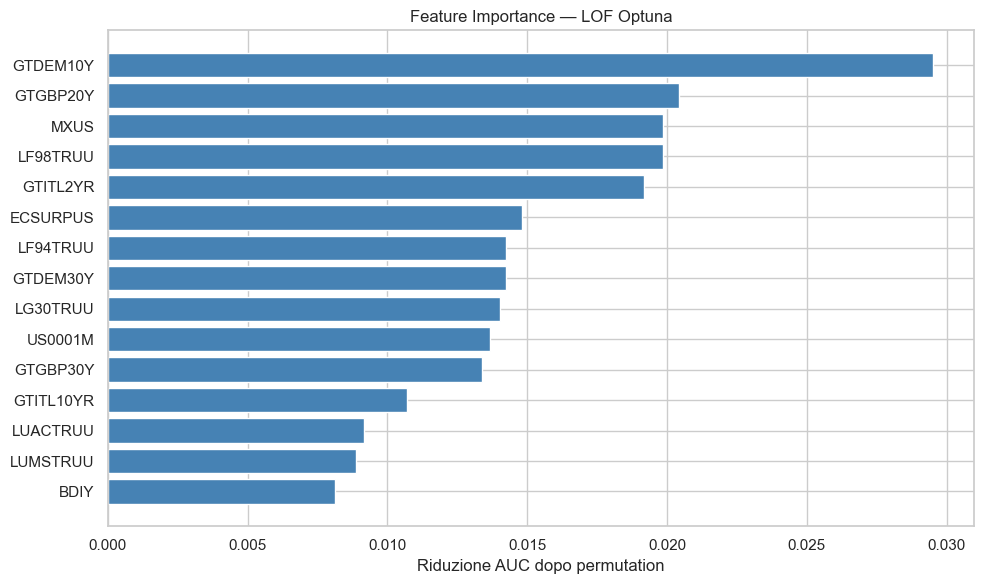

In [43]:
from sklearn.inspection import permutation_importance

# sul modello migliore — LOF Optuna
baseline_auc = roc_auc_score(y_test, lof_score)

importances = []
for i in range(X_test.shape[1]):
    X_test_permuted = X_test.copy()
    X_test_permuted[:, i] = np.random.permutation(X_test_permuted[:, i])
    score_perm = -best_lof.decision_function(X_test_permuted)
    auc_perm   = roc_auc_score(y_test, score_perm)
    importances.append(baseline_auc - auc_perm)

# bar chart
feat_names = stationary_df.columns.tolist()
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Riduzione AUC dopo permutation')
plt.title('Feature Importance — LOF Optuna')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.3 Analisi temporale — PCA Reconstruction

Applica il modello PCA Reconstruction sull'**intero dataset in ordine cronologico** 
(senza shuffle) per visualizzare l'andamento dell'anomaly score nel tempo.

Le zone rosse indicano i periodi classificati come anomalie reali nel dataset — 
corrispondenti a crisi storiche come la crisi finanziaria del 2008, la crisi 
del debito europeo del 2011 e il crollo Covid del 2020.

> Questo plot risponde alla domanda più importante dal punto di vista pratico: 
> *il modello avrebbe rilevato le crisi storiche in tempo utile?*

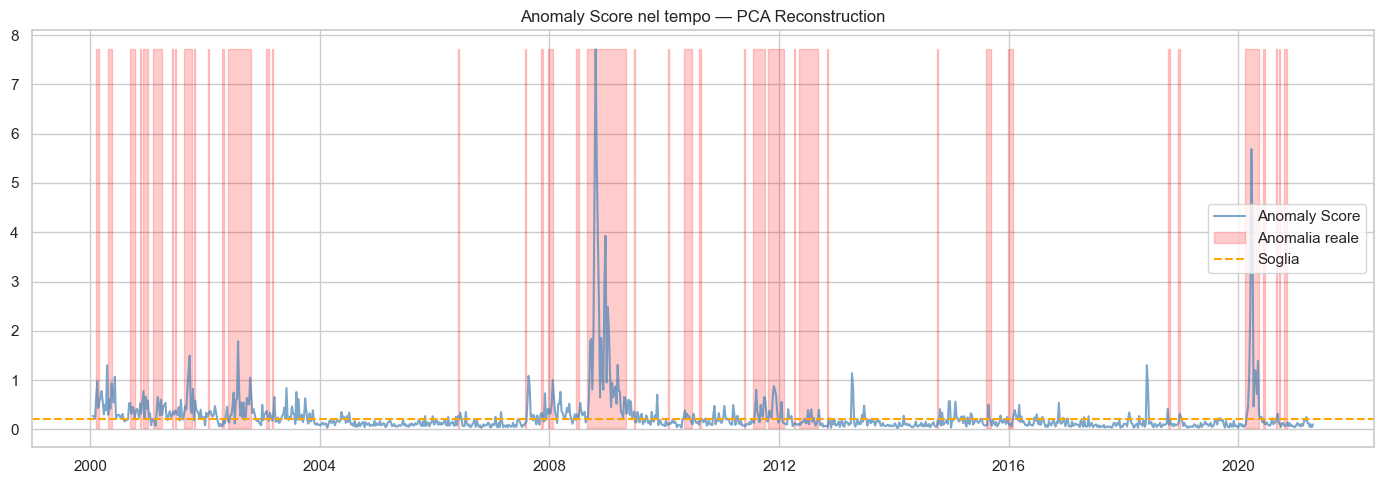

In [44]:
# ricostruisci l'indice temporale per il test set
# attenzione: dopo lo shuffle non c'è un ordine temporale diretto
# ma puoi farlo sul dataset completo senza shuffle

pca_full_model = PCA(n_components=best_k, random_state=42)
pca_full_model.fit(X_train)

# applica su tutto il dataset stazionario (scalato)
X_all_scaled = scaler.transform(stationary_df.values)
X_all_rec    = pca_full_model.inverse_transform(pca_full_model.transform(X_all_scaled))
all_scores   = np.mean((X_all_scaled - X_all_rec)**2, axis=1)
all_pred     = (all_scores > best_t).astype(int)

plt.figure(figsize=(14, 5))
plt.plot(stationary_df.index, all_scores, label='Anomaly Score', color='steelblue', alpha=0.7)
plt.fill_between(stationary_df.index,
                 all_scores.min(), all_scores.max(),
                 where=(y_stationary == 1),
                 alpha=0.2, color='red', label='Anomalia reale')
plt.axhline(best_t, color='orange', linestyle='--', label='Soglia')
plt.title('Anomaly Score nel tempo — PCA Reconstruction')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Filtro Direzionale — Analisi della Simmetria Boom/Crisi

I modelli di anomaly detection non supervisionati segnalano qualsiasi deviazione 
dalla normalità indipendentemente dalla direzione — inclusi rally coordinati 
(equity su, VIX giù, spread tight) che sono anomali statisticamente ma non 
richiedono una risposta difensiva. Questo problema di simmetria è formalizzato 
da Sornette (2009) nella distinzione tra Black Swan (crisi esogene imprevedibili) 
e Dragon King (crisi endogene con segnale direzionale nelle serie storiche).

Implementiamo un filtro direzionale come post-processing sulle predizioni di 
tutti i modelli: per ogni punto classificato come anomalia, calcoliamo la sua 
proiezione sulla direzione risk-off nello spazio delle 42 feature e sopprimiamo 
i segnali che puntano nella direzione opposta (risk-on).

La direzione risk-off viene stimata come differenza normalizzata tra la media 
delle anomalie e la media dei normali nel CV set — senza parametri aggiuntivi 
da ottimizzare.

In [45]:
# ── Direzione risk-off ───────────────────────────────────────────────────────
mean_normal  = X_cross_val[y_cross_val == 0].mean(axis=0)
mean_anomaly = X_cross_val[y_cross_val == 1].mean(axis=0)

risk_off_dd = mean_anomaly - mean_normal
risk_off_dd = risk_off_dd / np.linalg.norm(risk_off_dd)

# proiezioni su CV e test
proj_cv_dd = X_cross_val @ risk_off_dd
proj_dd    = X_test      @ risk_off_dd

print("── Separazione direzionale ──────────────────────────")
print(f"Normali  — proiezione media: {proj_dd[y_test==0].mean():.3f}")
print(f"Anomalie — proiezione media: {proj_dd[y_test==1].mean():.3f}")
print(f"Gap:                         {proj_dd[y_test==1].mean() - proj_dd[y_test==0].mean():.3f}")

# ── Funzione filtro ──────────────────────────────────────────────────────────
def apply_directional_filter(pred, projections, threshold=0.0):
    pred_filtered = pred.copy()
    pred_filtered[(pred == 1) & (projections <= threshold)] = 0
    return pred_filtered

# ── Soglia conservativa: 5° percentile delle anomalie reali nel CV ───────────
conservative_thresh = np.percentile(proj_cv_dd[y_cross_val == 1], 5)
print(f"\nSoglia conservativa (5° pct anomalie CV): {conservative_thresh:.4f}")

# ── Applica il filtro a tutti i modelli con entrambe le soglie ───────────────
models_to_filter = {
    'Isolation Forest':          (iso_pred,   iso_score),
    'One-Class SVM':             (ocsvm_pred, ocsvm_score),
    'LOF':                       (lof_pred,   lof_score),
    'GMM 2 components':          (gmm_pred,   gmm_test_score),
    'COPOD':                     (copod_pred, copod_score),
    'ECOD':                      (ecod_pred,  ecod_score),
    'PCA Reconstruction':        (pca_pred,   pca_score),
    'HBOS':                      (hbos_pred,  hbos_score),
    'LOF (Optuna)':              (lof_pred,   lof_score),
    'Isolation Forest (Optuna)': (if_pred,    if_score),
    'One-Class SVM (Optuna)':    (ocsvm_pred, ocsvm_score),
}

print(f"\n{'─'*75}")
print(f"{'Modello':30} {'F1 orig':>8} {'F1 t=0':>8} {'Δ t=0':>8} {'F1 cons':>8} {'Δ cons':>8}")
print(f"{'─'*75}")

delta_t0, delta_cons = [], []

for name, (pred, score) in models_to_filter.items():
    f1_orig = f1_score(y_test, pred, zero_division=0)

    pred_t0   = apply_directional_filter(pred, proj_dd, threshold=0.0)
    pred_cons = apply_directional_filter(pred, proj_dd, threshold=conservative_thresh)

    f1_t0   = f1_score(y_test, pred_t0,   zero_division=0)
    f1_cons = f1_score(y_test, pred_cons, zero_division=0)

    d_t0   = f1_t0   - f1_orig
    d_cons = f1_cons - f1_orig

    delta_t0.append(d_t0)
    delta_cons.append(d_cons)

    print(f"{name:30} {f1_orig:>8.4f} {f1_t0:>8.4f} {d_t0:>+8.4f} "
          f"{f1_cons:>8.4f} {d_cons:>+8.4f}")

print(f"{'─'*75}")
print(f"{'Media':30} {'':>8} {'':>8} {np.mean(delta_t0):>+8.4f} "
      f"{'':>8} {np.mean(delta_cons):>+8.4f}")

── Separazione direzionale ──────────────────────────
Normali  — proiezione media: -0.331
Anomalie — proiezione media: 2.634
Gap:                         2.965

Soglia conservativa (5° pct anomalie CV): -4.8749

───────────────────────────────────────────────────────────────────────────
Modello                         F1 orig   F1 t=0    Δ t=0  F1 cons   Δ cons
───────────────────────────────────────────────────────────────────────────
Isolation Forest                 0.7294   0.6373  -0.0922   0.7206  -0.0088
One-Class SVM                    0.7533   0.6870  -0.0664   0.7466  -0.0068
LOF                              0.7376   0.6377  -0.1000   0.7294  -0.0082
GMM 2 components                 0.6844   0.5543  -0.1301   0.6697  -0.0147
COPOD                            0.7120   0.6368  -0.0752   0.7025  -0.0095
ECOD                             0.6835   0.5864  -0.0972   0.6725  -0.0111
PCA Reconstruction               0.6844   0.5792  -0.1052   0.6728  -0.0116
HBOS                        

**Risultato:** il filtro direzionale peggiora F1 su tutti gli 11 modelli 
indipendentemente dalla soglia utilizzata.

| Soglia | Delta F1 medio |
|---|---|
| Aggressiva (t = 0.0) | -0.0919 |
| Conservativa (t = -4.87) | -0.0094 |

La direzione risk-off separa correttamente normali da anomalie — gap di 
proiezione pari a **2.965** (normali: -0.331, anomalie: +2.634) — confermando 
che la firma finanziaria delle crisi è presente e coerente con le aspettative: 
VIX su, equity giù, oro su durante i periodi risk-off.

Il filtro non migliora le performance perché nel dataset 2000-2021 i rally 
estremi coordinati sono rari rispetto alle crisi. Il periodo coperto include 
la crisi dot-com (2001), la GFC (2008), la crisi del debito europeo (2011), 
il crollo cinese (2015) e il Covid (2020) — tutti eventi risk-off. I falsi 
allarmi da rally che il filtro dovrebbe sopprimere non sono sufficientemente 
numerosi nel test set da giustificare la perdita di Recall che il filtro 
introduce in cambio.

Il modello più penalizzato dalla soglia aggressiva è **GMM** (ΔF1 = -0.1301), 
che già soffriva di Recall basso — il filtro aggrava ulteriormente la perdita 
di anomalie reali. Il modello più robusto al filtro è **One-Class SVM (Optuna)** 
(ΔF1 = -0.0068 con soglia conservativa), grazie al Recall molto alto (0.95) 
che assorbe meglio la perdita di alcuni veri positivi.

Il filtro direzionale risulterebbe più efficace su dataset che includono 
periodi di euforia prolungata come il bull market 1995-1999 o 2017-2018, 
dove i modelli statistici tenderebbero a generare falsi allarmi sistematici 
in direzione risk-on.

Questo è un **risultato negativo informativo**: conferma che i modelli 
non supervisionati classici, su questo dataset, non soffrono significativamente 
del problema di simmetria identificato da Sornette (2009).

## 8. Conclusioni

### Risultati principali

I modelli testati si dividono in due famiglie con trade-off opposti:

**Alta Recall, bassa Precision** → LOF, Isolation Forest, One-Class SVM, HBOS  
Catturano la maggior parte delle crisi al costo di più falsi allarmi.  
Preferibili in contesti di **risk management** dove una crisi mancata è 
più costosa di un falso allarme.

**Alta Precision, bassa Recall** → GMM, PCA Reconstruction  
Quando segnalano un'anomalia hanno quasi sempre ragione, ma si perdono molte crisi.  
Preferibili in contesti di **alpha generation** dove i falsi segnali hanno 
costi elevati.

### Modelli migliori per metrica

| Metrica | Modello | Valore |
|---|---|---|
| F1 | One-Class SVM (Optuna) | 0.7533 |
| AUC | GMM 2 components | 0.7552 |
| Recall | One-Class SVM (Optuna) | 0.9496 |
| Precision | PCA Reconstruction | 0.7264 |

**One-Class SVM (Optuna)** è il modello più adatto a un sistema di risk 
management — cattura il 95% delle crisi reali al costo di una Precision 
più bassa (0.62). In questo contesto il trade-off è accettabile: meglio 
un falso allarme in più che una crisi mancata.

**GMM** ha l'AUC più alto (0.755) — il suo score grezzo separa meglio di 
tutti normali da anomalie, ma la soglia fissa derivata dalla contamination 
non sfrutta completamente questo potenziale. Con un tuning più sofisticato 
della soglia potrebbe diventare il modello migliore per F1.

### Effetto dell'ottimizzazione con Optuna

Optuna migliora i baseline su tutti e tre i modelli ottimizzati quando la 
contamination usata è quella reale del dataset (~21%) invece di quella 
artificiale del CV set (50%). Questo conferma che la stima della contamination 
è il parametro più critico nei modelli non supervisionati — più importante 
della scelta degli iperparametri strutturali.

### Filtro direzionale

Il filtro direzionale ispirato a Sornette (2009) — che sopprime i segnali 
di anomalia nella direzione risk-on per ridurre i falsi allarmi da rally — 
non migliora le performance su questo dataset (ΔF1 medio = -0.0094 con 
soglia conservativa). La firma direzionale delle crisi è presente e ben 
separata (gap di proiezione: 2.965), ma i falsi allarmi da rally non sono 
sufficientemente numerosi nel periodo 2000-2021 da giustificare la perdita 
di Recall che il filtro introduce. Il filtro risulterebbe più efficace su 
dataset che includono periodi di euforia prolungata come il bull market 
1995-1999 o 2017-2018.

### Tabella pro/contro

| Modello | Decision Boundary | Labels needed | Contamination needed | Pro | Contro |
|---|---|---|---|---|---|
| Isolation Forest | Non-lineare (tree) | No | Sì | Veloce, scalabile | Soffre in bassa dimensione |
| One-Class SVM | Non-lineare (kernel) | No | Sì | Flessibile | Lento, sensibile a gamma |
| LOF | Densità locale | No | Sì | Rileva anomalie locali | Soffre in alta dimensione |
| GMM | Probabilistico (ellissoidi) | No | No | AUC migliore, due regimi | Assume gaussianità |
| COPOD | Non parametrico (copule) | No | Sì | Robusto a fat tails | Assume tail independence |
| ECOD | Non parametrico (ECDF) | No | Sì | Velocissimo, recente | Ignora dipendenze tra feature |
| PCA | Lineare | No | No | Interpretabile, motivazione finanziaria | Assume struttura lineare |
| HBOS | Istogramma per feature | No | Sì | Semplicissimo, veloce | Ignora dipendenze tra feature |